# Deep-Learning Assisted Eigenmode Retrieval

We attempt to make predictions on subsequent turbulence eigenmodes with the help of deep learning. We use a Fourier Neural Operator, which is well suited to learn nonlinear functions which applies transformations in the fourier domain.

In [1]:
import torch
import torch.nn as nn
import os
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
from LightPipes import *

import fno
from fno import FNO2d, spectral_relative_l2, make_freq_weights

# Begin by loading up the dataset

In [2]:

NPZ_PATH = "dataset2.npz"  # single pre-converted .npz file — edit 

data = np.load(NPZ_PATH)

print(f"Loaded dataset from '{NPZ_PATH}'")
print(f"Keys    : {list(data.keys())}")
print(f"Samples : {data['gaussian_forward_real'].shape[0]}")
print(f"Grid    : {data['gaussian_forward_real'].shape[1:]} (H x W)")


Loaded dataset from 'dataset2.npz'
Keys    : ['eigenmode_1_real', 'eigenmode_2_real', 'eigenmode_3_real', 'eigenmode_4_real', 'eigenmode_1_imag', 'eigenmode_2_imag', 'eigenmode_3_imag', 'eigenmode_4_imag', 'gaussian_forward_real', 'gaussian_forward_imag', 'gaussian_reversed_real', 'gaussian_reversed_imag']
Samples : 10001
Grid    : (64, 64) (H x W)
Grid    : (64, 64) (H x W)


For each time step, we have information about four turbulence eigenmodes, as well as the gaussian mode going forwards and backwards.

The samples in our dataset must be prepared as single-step predictors, meaning that they are input-output pairs of the form $(E_{t}, P_{t+1}) \rightarrow E_{t+1}$

In [3]:
N_EIGENMODES = 4

def prepare_pairs(data, n_eigenmodes=N_EIGENMODES):
    """
    Build single-step predictor pairs from the .npz dataset.

    For each consecutive pair of timesteps (t, t+1) and each eigenmode k we form:
      - Input  : [eigenmode_k_real_t,        eigenmode_k_imag_t,
                  gaussian_forward_real_t+1,  gaussian_forward_imag_t+1,
                  gaussian_reversed_real_t+1, gaussian_reversed_imag_t+1]  → (H, W, 6)
      - Target : [eigenmode_k_real_{t+1}, eigenmode_k_imag_{t+1}]          → (H, W, 2)

    Parameters
    ----------
    data : np.lib.npyio.NpzFile
        Loaded .npz file with arrays of shape (N_samples, H, W) per key.

    Returns
    -------
    X : torch.Tensor  shape ((N-1)*n_eigenmodes, H, W, 6)
    Y : torch.Tensor  shape ((N-1)*n_eigenmodes, H, W, 2)
    """
    N_samples = data["gaussian_forward_real"].shape[0]
    H, W      = data["gaussian_forward_real"].shape[1:]
    N_pairs   = N_samples - 1
    total     = N_pairs * n_eigenmodes

    # Pre-allocate output arrays — no repeated reallocation
    X = np.empty((total, H, W, 6), dtype=np.float32)
    Y = np.empty((total, H, W, 2), dtype=np.float32)

    # Slice Gaussian arrays once — shared across all eigenmodes
    gfwd_real = data["gaussian_forward_real"][1:].astype(np.float32)   # (N-1, H, W)
    gfwd_imag = data["gaussian_forward_imag"][1:].astype(np.float32)
    grev_real = data["gaussian_reversed_real"][1:].astype(np.float32)
    grev_imag = data["gaussian_reversed_imag"][1:].astype(np.float32)

    for k in range(1, n_eigenmodes + 1):
        print(f"Processing eigenmode {k}/{n_eigenmodes} ...")
        idx = slice((k - 1) * N_pairs, k * N_pairs)

        em_real = data[f"eigenmode_{k}_real"].astype(np.float32)   # (N, H, W)
        em_imag = data[f"eigenmode_{k}_imag"].astype(np.float32)

        X[idx, ..., 0] = em_real[:N_pairs]   # eigenmode at t
        X[idx, ..., 1] = em_imag[:N_pairs]
        X[idx, ..., 2] = gfwd_real            # Gaussian forward at t+1
        X[idx, ..., 3] = gfwd_imag
        X[idx, ..., 4] = grev_real            # Gaussian reversed at t+1
        X[idx, ..., 5] = grev_imag

        Y[idx, ..., 0] = em_real[1:]          # eigenmode at t+1
        Y[idx, ..., 1] = em_imag[1:]

    return torch.from_numpy(X), torch.from_numpy(Y)

X, Y = prepare_pairs(data)

print(f"Input  shape : {X.shape}")   # ((N-1)*4, H, W, 6)
print(f"Target shape : {Y.shape}")   # ((N-1)*4, H, W, 2)


Processing eigenmode 1/4 ...
Processing eigenmode 2/4 ...
Processing eigenmode 2/4 ...
Processing eigenmode 3/4 ...
Processing eigenmode 3/4 ...
Processing eigenmode 4/4 ...
Processing eigenmode 4/4 ...
Input  shape : torch.Size([40000, 64, 64, 6])
Target shape : torch.Size([40000, 64, 64, 2])
Input  shape : torch.Size([40000, 64, 64, 6])
Target shape : torch.Size([40000, 64, 64, 2])


Prepare the dataset for training/test

In [4]:
n_train = int(0.90*X.shape[0])
batch_size = 10

x_train =  X[:n_train]
x_test =  X[n_train:]

y_train = Y[:n_train]
y_test = Y[n_train:]

N = x_train.shape[2]

training_set = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
testing_set = DataLoader(TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False)


In [5]:
x_batch, y_batch = next(iter(training_set))
print(x_batch.shape)

torch.Size([10, 64, 64, 6])


Instantiate the FNO architecture

In [6]:
epochs = 25

# These control the step-wise updates on the LR

learn_rate = 0.001 # initial LR
step_size = 12 # Number of epochs after which we apply a decay in the learning rate
gamma = 0.5 # factor by whcih we alter the LR

# Parameters we specify the neural network architecture

modes1 = 36 # number of spectral modes along one dimension
modes2 = 36 # number of spectral modes along another dimension
width = 64 # number of neurons in each layer? 
n_layers = 1 # Number of layers
retrain_fno = 42 # This specifies the seed that initializes the FNO parameters

input_chans = 6
output_chans = 2

# Physical parameters 
size = 0.45 #(simulation window)
lensSize = 0.1125 #(size/4)

fno_architecture = {"modes1": modes1, "modes2":modes2, "width":width, "n_layers":n_layers, "retrain_fno":retrain_fno, "input_chans":input_chans, "output_chans":output_chans}


Load up GPU (if not already done so)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

Is CUDA available? True
GPU Name: NVIDIA GeForce RTX 5060 Laptop GPU
Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)


To avoid confusion, we apply an aperture on the output predicted channel. 

In [8]:
def torch_circ_aperture(field_batch: torch.Tensor, size: float, lensSize: float) -> torch.Tensor:
    """
    Applies a circular aperture to a batch of complex fields represented
    as real/imaginary channels.

    Parameters
    ----------
    field_batch : torch.Tensor  shape (batch, H, W, C)
                  where C=2 holds [real, imag] channels
    size        : float — physical side length of the window (metres)
    lensSize    : float — aperture radius (metres)

    Returns
    -------
    torch.Tensor — same shape as field_batch, zeroed outside the aperture
    """
    _, H, W, _ = field_batch.shape
    device = field_batch.device

    # Build physical coordinate axes centred at zero — same convention as LightPipes
    x = torch.linspace(-size / 2, size / 2, W, device=device)
    y = torch.linspace(-size / 2, size / 2, H, device=device)
    yy, xx = torch.meshgrid(y, x, indexing="ij")   # (H, W)

    # Binary mask: 1 inside aperture, 0 outside
    mask = (xx**2 + yy**2 <= lensSize**2).float()  # (H, W)
    mask = mask.unsqueeze(0).unsqueeze(-1)          # (1, H, W, 1) — broadcasts over batch and channels

    return field_batch * mask

Now train the FNO

In [9]:
use_mse_loss = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Instantiate the model and move to GPU
fno = FNO2d(fno_architecture, device=device)

optim = Adam(fno.parameters(), lr=learn_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=step_size, gamma=gamma)

if use_mse_loss:
    loss = torch.nn.MSELoss()
else:
    # Build a weight map once before the loop
    freq_weights = make_freq_weights(N, k_cutoff_frac=0.99, alpha=2.0, device=device)

freq_print = 1

n_train_batches = len(training_set)
n_test_batches = len(testing_set)

train_mse_history = []
test_rel_l2_history = []

for epoch in range(epochs):

    # Evaluate the training MSE

    train_mse = 0.0

    for step, (input_batch, output_batch) in enumerate(training_set):
        input_batch = input_batch.to(device)
        output_batch = output_batch.to(device)
        optim.zero_grad()
        output_pred_batch = torch_circ_aperture(fno(input_batch), size=size, lensSize=lensSize) 

        # (batch, H, W, 2)

        if (use_mse_loss):
            loss_f = loss(output_pred_batch, output_batch)
    
        else:
            loss_f = spectral_relative_l2(output_pred_batch, output_batch, freq_weights)
        
        loss_f.backward()
        optim.step()
        train_mse += loss_f.item()
        batches_left = n_train_batches - (step + 1)
        print(f"  [Epoch {epoch+1}/{epochs} | Train batch {step+1}/{n_train_batches} | Batches left: {batches_left}] Batch Loss: {loss_f.item():.6f}")
    train_mse /= n_train_batches

    print("Training batches computed")

    scheduler.step()

    with torch.no_grad():
        fno.eval()
        test_relative_l2 = 0.0
        for step, (input_batch, output_batch) in enumerate(testing_set):
            input_batch = input_batch.to(device)
            output_batch = output_batch.to(device)
            output_pred_batch = torch_circ_aperture(fno(input_batch), size=size, lensSize=lensSize)  # (batch, H, W, 2)
        
            if use_mse_loss:
                loss_f = (torch.mean((output_pred_batch - output_batch) ** 2) / torch.mean(output_batch ** 2)) ** 0.5 * 100  # Relative L2 Norm
            else:
                loss_f = spectral_relative_l2(output_pred_batch, output_batch, freq_weights)

            test_relative_l2 += loss_f.item()
            batches_left = n_test_batches - (step + 1)
            print(f"  [Epoch {epoch+1}/{epochs} | Test  batch {step+1}/{n_test_batches}  | Batches left: {batches_left}] Relative L2: {loss_f.item():.4f}%")
        test_relative_l2 /= n_test_batches

    train_mse_history.append(train_mse)
    test_rel_l2_history.append(test_relative_l2)

    if epoch % freq_print == 0:
        print(f"========= Epoch {epoch+1}/{epochs} Summary ========= Train MSE: {train_mse:.6f} | Mean Relative L2 Test: {test_relative_l2:.4f}%\n")


Using device: cuda (NVIDIA GeForce RTX 5060 Laptop GPU)
  [Epoch 1/25 | Train batch 1/3600 | Batches left: 3599] Batch Loss: 5.958423
  [Epoch 1/25 | Train batch 2/3600 | Batches left: 3598] Batch Loss: 3.456238
  [Epoch 1/25 | Train batch 3/3600 | Batches left: 3597] Batch Loss: 3.229984
  [Epoch 1/25 | Train batch 4/3600 | Batches left: 3596] Batch Loss: 2.946946
  [Epoch 1/25 | Train batch 5/3600 | Batches left: 3595] Batch Loss: 2.658971
  [Epoch 1/25 | Train batch 6/3600 | Batches left: 3594] Batch Loss: 2.183582
  [Epoch 1/25 | Train batch 7/3600 | Batches left: 3593] Batch Loss: 2.373448
  [Epoch 1/25 | Train batch 8/3600 | Batches left: 3592] Batch Loss: 2.497635
  [Epoch 1/25 | Train batch 9/3600 | Batches left: 3591] Batch Loss: 2.598858
  [Epoch 1/25 | Train batch 10/3600 | Batches left: 3590] Batch Loss: 2.033438
  [Epoch 1/25 | Train batch 1/3600 | Batches left: 3599] Batch Loss: 5.958423
  [Epoch 1/25 | Train batch 2/3600 | Batches left: 3598] Batch Loss: 3.456238
  [Epoc

KeyboardInterrupt: 

Save the model (if applicable)

In [13]:

models_dir = "trained_models_eigen"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "fno_eigen.pth")

torch.save({
    "model_state_dict": fno.state_dict(),
    "optimizer_state_dict": optim.state_dict(),
    "fno_architecture": fno_architecture,
    "epochs": epochs,
    "train_mse_history": train_mse_history,
    "test_rel_l2_history": test_rel_l2_history,
}, model_path)

print(f"Model saved to {model_path}")

Model saved to trained_models_eigen\fno_eigen.pth


Make a plot

Plot saved to training_plots/training_curves.png


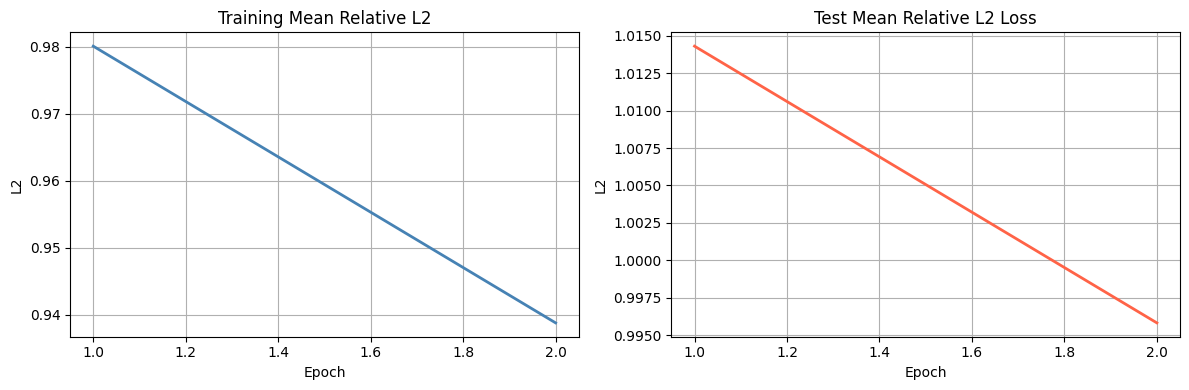

In [10]:
import os


epochs=2
epochs_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_mse_history, color='steelblue', linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("L2")
axes[0].set_title("Training Mean Relative L2")
axes[0].grid(True)

axes[1].plot(epochs_range, test_rel_l2_history, color='tomato', linewidth=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("L2")
axes[1].set_title("Test Mean Relative L2 Loss")
axes[1].grid(True)

plt.tight_layout()

plots_dir = "training_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, "training_curves.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/training_curves.png")

plt.show()

# Inference

How does our network do on infering the propagation of the network?

In [15]:
# Load the model checkpoint (if applicable)

checkpoint = torch.load("trained_models_eigen/fno_eigen.pth")
fno = FNO2d(checkpoint["fno_architecture"], device=device)
fno.load_state_dict(checkpoint["model_state_dict"])

sample_index = 50
input_sample = x_test[sample_index, :, :, :].unsqueeze(0).to(device)

# Extract the propagated field distance for reference

output_dist = input_sample[0,0,0,0]
print(output_dist)

fno.eval()
with torch.no_grad():
    output_pred = fno(input_sample)

# Reconstruct field from real and imaginary components

output_pred = output_pred.squeeze(0).cpu().numpy()
output_field = output_pred[..., 0] + 1j*output_pred[..., 1]

tensor(0., device='cuda:0')


In [16]:
checkpoint["fno_architecture"]

{'modes1': 36,
 'modes2': 36,
 'width': 64,
 'n_layers': 1,
 'retrain_fno': 42,
 'input_chans': 6,
 'output_chans': 2}

Plot the input/output prediction

Plot saved to inference_plots/inference_sample90.png


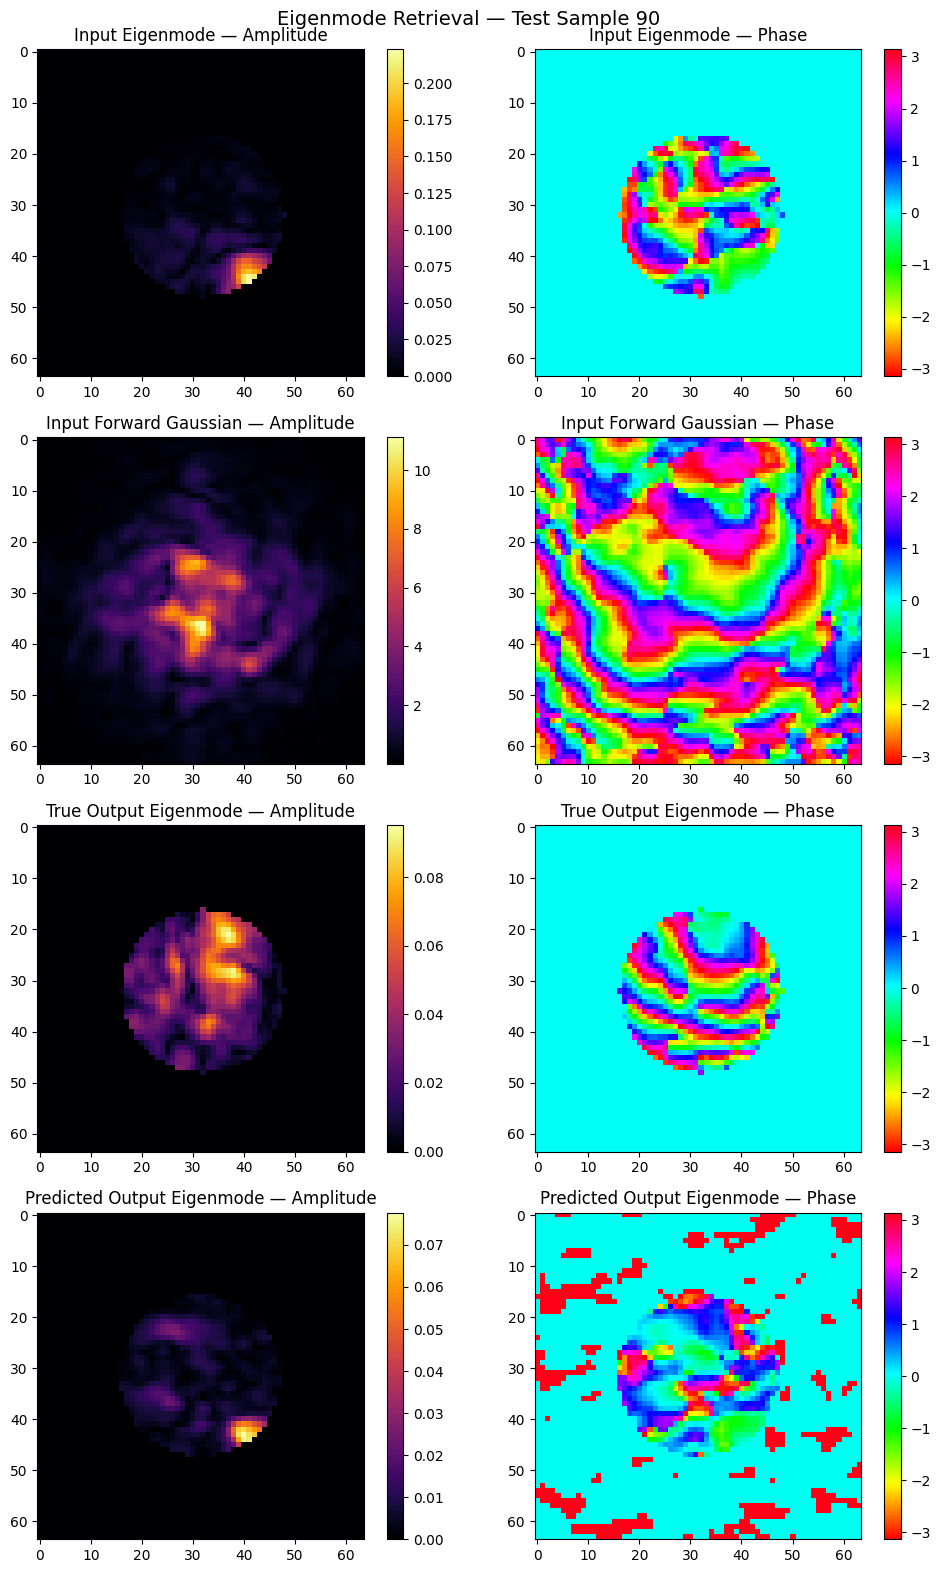

In [20]:
sample_index = 90
# --- Inference ---
input_sample = x_test[sample_index].unsqueeze(0).to(device)  # (1, H, W, 4)

fno.eval()
with torch.no_grad():
    output_pred = torch_circ_aperture(fno(input_sample), size=size, lensSize=lensSize)  # (1, H, W, 2)

# --- Extract fields from input ---
input_np = x_test[sample_index].cpu().numpy()          # (H, W, 4)
eigenmode_in  = input_np[..., 0] + 1j * input_np[..., 1]   # channels 0,1
gaussian_fwd  = input_np[..., 2] + 1j * input_np[..., 3]   # channels 2,3

# --- Ground truth output eigenmode ---
output_true_np = y_test[sample_index].cpu().numpy()    # (H, W, 2)
eigenmode_true = output_true_np[..., 0] + 1j * output_true_np[..., 1]

# --- Predicted output eigenmode ---
output_pred_np = output_pred.squeeze(0).cpu().numpy()  # (H, W, 2)
eigenmode_pred = output_pred_np[..., 0] + 1j * output_pred_np[..., 1]

# --- Plot ---
fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle(f"Eigenmode Retrieval — Test Sample {sample_index}", fontsize=14)

rows = [
    (eigenmode_in,   "Input Eigenmode"),
    (gaussian_fwd,   "Input Forward Gaussian"),
    (eigenmode_true, "True Output Eigenmode"),
    (eigenmode_pred, "Predicted Output Eigenmode"),
]

for i, (field, title) in enumerate(rows):
    im_amp = axes[i, 0].imshow(np.abs(field), cmap='inferno')
    axes[i, 0].set_title(f"{title} — Amplitude")
    plt.colorbar(im_amp, ax=axes[i, 0])

    im_ph = axes[i, 1].imshow(np.angle(field), cmap='hsv')
    axes[i, 1].set_title(f"{title} — Phase")
    plt.colorbar(im_ph, ax=axes[i, 1])

plt.tight_layout()

plots_dir = "inference_plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(os.path.join(plots_dir, f"inference_sample{sample_index}.png"), dpi=150, bbox_inches="tight")
print(f"Plot saved to {plots_dir}/inference_sample{sample_index}.png")

plt.show()